In [7]:

# Step 1: Load the Dataset (from your uploaded parquet files)

import pandas as pd
import numpy as np
import re
import string

train_df = pd.read_parquet("train-00000-of-00001.parquet")
test_df = pd.read_parquet("test-00000-of-00001.parquet")

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

num_classes = train_df["label"].nunique()
print(f"Train samples: {len(train_texts)}, Test samples: {len(test_texts)}, Classes: {num_classes}")

Train samples: 120000, Test samples: 7600, Classes: 4


In [8]:
train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [2]:
# Step 2: Clean and Normalize the Text

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_texts_clean = [clean_text(t) for t in train_texts]
test_texts_clean = [clean_text(t) for t in test_texts]

print("Example before:", train_texts[0][:80])
print("Example after :", train_texts_clean[0][:80])

Example before: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall 
Example after : wall st bears claw back into the black reuters reuters shortsellers wall streets


In [3]:
# Step 3: Tokenize the Strings into Numbers
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts_clean)   # fit ONLY on training data

train_sequences = tokenizer.texts_to_sequences(train_texts_clean)
test_sequences = tokenizer.texts_to_sequences(test_texts_clean)

print("Sample sequence:", train_sequences[0][:10])

Sample sequence: [392, 325, 1526, 1, 100, 55, 2, 813, 24, 24]


In [9]:
# Step 5: Convert Labels to Categorical Vectors
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_labels, num_classes=num_classes)
y_test = to_categorical(test_labels, num_classes=num_classes)

print("Label example:", train_labels[0], "->", y_train[0])

Label example: 2 -> [0. 0. 1. 0.]


In [10]:
# Step 6: Define the RNN Model Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

EMBEDDING_DIM = 64
RNN_UNITS = 64

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(RNN_UNITS),
    Dense(num_classes, activation="softmax")
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Step 7: Compile and Train the Model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 68s 22ms/step - accuracy: 0.7311 - loss: 0.7696 - val_accuracy: 0.4185 - val_loss: 1.0673
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 59s 20ms/step - accuracy: 0.3416 - loss: 1.3159 - val_accuracy: 0.3441 - val_loss: 1.3124
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 61s 20ms/step - accuracy: 0.3630 - loss: 1.2909 - val_accuracy: 0.3512 - val_loss: 1.3036
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 60s 20ms/step - accuracy: 0.5444 - loss: 1.0556 - val_accuracy: 0.6440 - val_loss: 0.9864
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 62s 21ms/step - accuracy: 0.7080 - loss: 0.8063 - val_accuracy: 0.6485 - val_loss: 0.9275
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 81s 20ms/step - accuracy: 0.7072 - loss: 0.7497 - val_accuracy: 0.6109 - val_loss: 1.0061
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 60s 20ms/step - accuracy: 0.6692 - loss: 0.8577 - val_accuracy: 0.6295 - val_loss: 0.9303
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 59s 20ms/step - accuracy: 0.6789 -

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5779 - loss: 0.9678
Test Loss: 0.9678
Test Accuracy: 0.5779


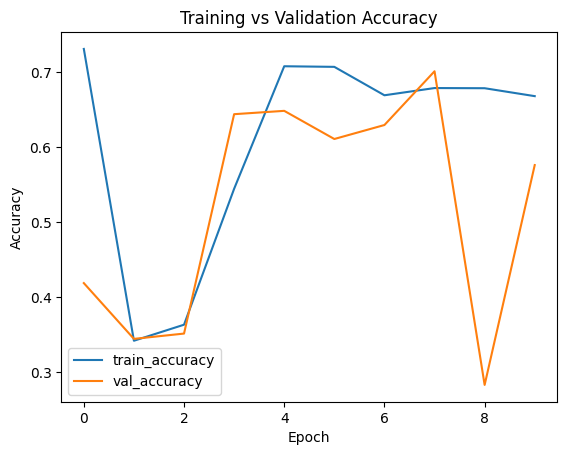

In [12]:
# Step 8: Read and Evaluate the Target Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.savefig("accuracy_plot.png")
plt.show()